In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

import warnings
warnings.filterwarnings('ignore')

data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

print(df.shape)
print(df['target'].value_counts())

(569, 31)
target
1    357
0    212
Name: count, dtype: int64


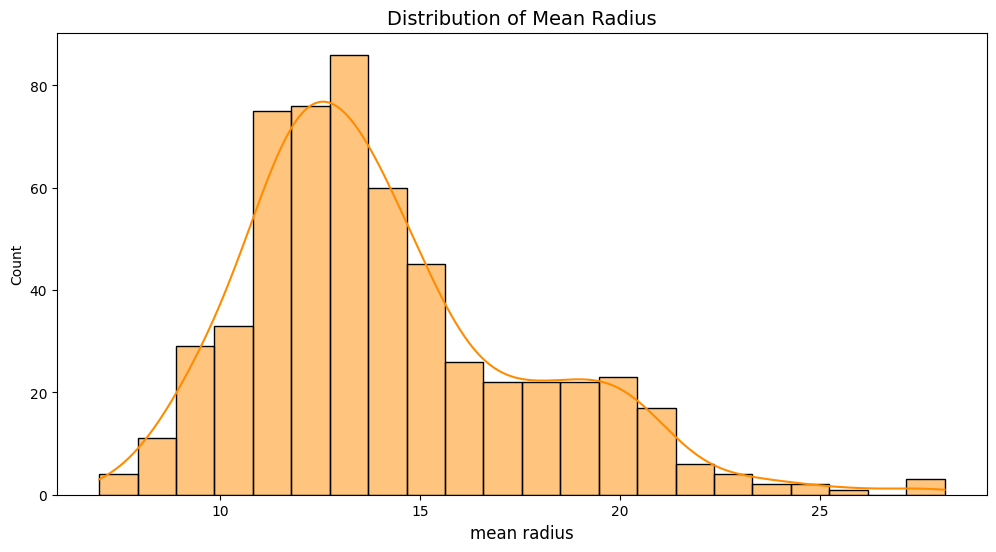

In [2]:
plt.figure(figsize=(12, 6))
sns.histplot(df['mean radius'], kde=True, color='darkorange')
plt.xlabel('mean radius', fontsize=12)
plt.title('Distribution of Mean Radius', fontsize=14)
plt.show()

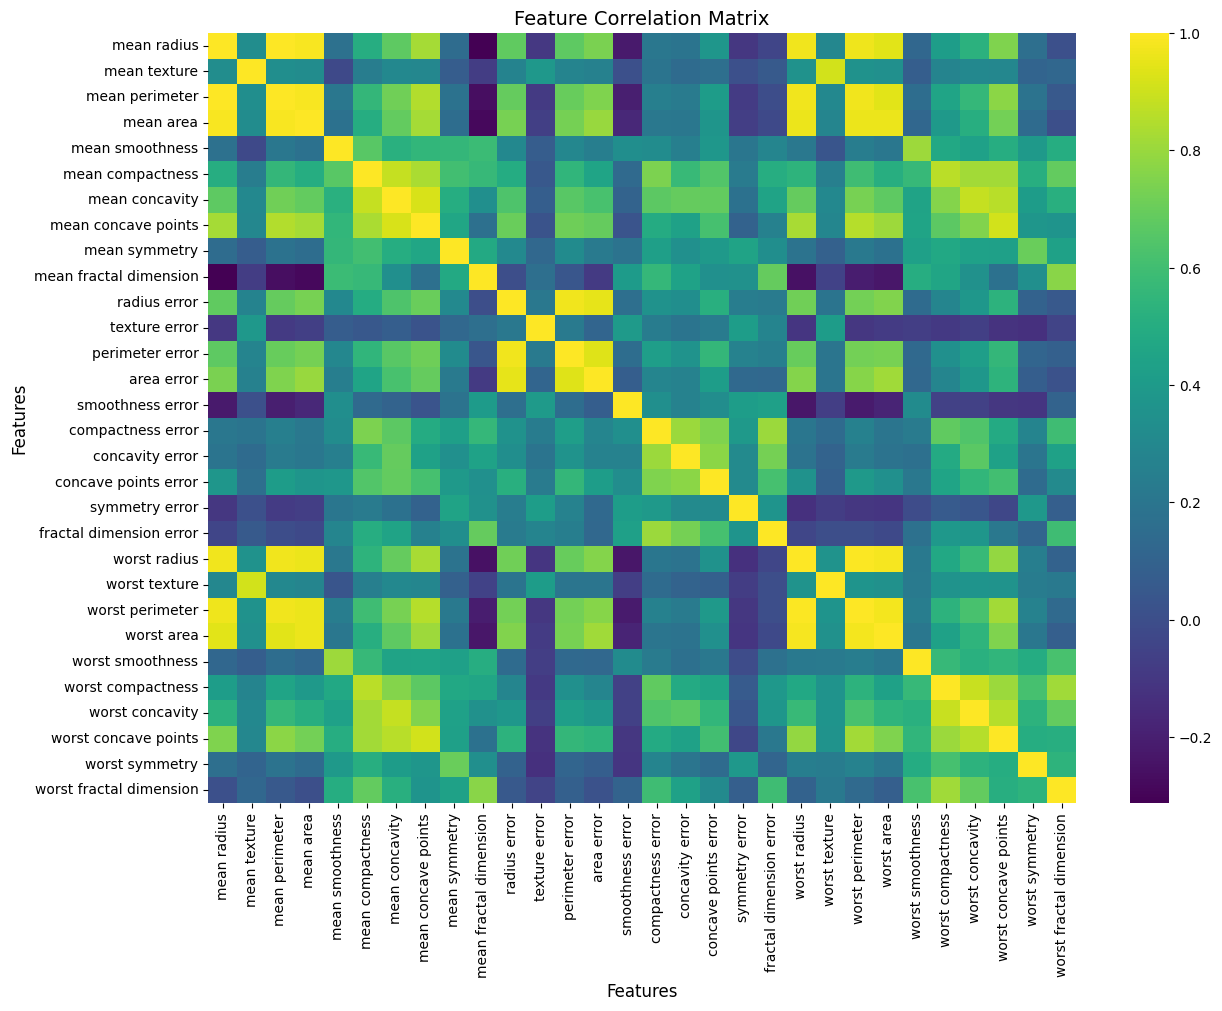

In [3]:
plt.figure(figsize=(14, 10))
corr_matrix = df.drop('target', axis=1).corr()
sns.heatmap(corr_matrix, cmap='viridis', annot=False)
plt.xlabel('Features', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.title('Feature Correlation Matrix', fontsize=14)
plt.show()

In [4]:
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# 可以不要标准化
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(X_test_scaled.shape[0])

171


In [5]:
gbc = GradientBoostingClassifier(random_state=42)
gbc.fit(X_train_scaled, y_train)

y_pred = gbc.predict(X_test_scaled)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.91      0.93        64
           1       0.95      0.97      0.96       107

    accuracy                           0.95       171
   macro avg       0.95      0.94      0.94       171
weighted avg       0.95      0.95      0.95       171



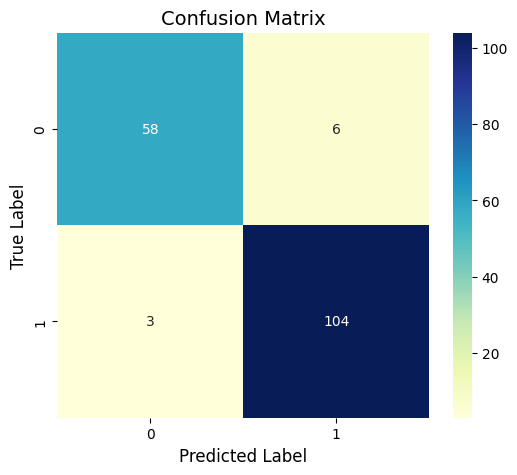

In [6]:
cm = confusion_matrix(y_test, y_pred)  # 输入顺序必须要是真实、预测
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title('Confusion Matrix', fontsize=14)
plt.show()

最佳参数： {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 150}
最佳交叉验证得分： 0.9625
分类报告（Optimized Parameters）:
              precision    recall  f1-score   support

           0       0.97      0.89      0.93        64
           1       0.94      0.98      0.96       107

    accuracy                           0.95       171
   macro avg       0.95      0.94      0.94       171
weighted avg       0.95      0.95      0.95       171



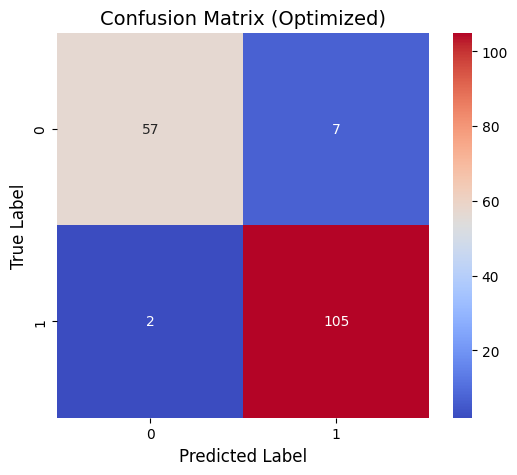

In [7]:
# 定义超参数网格
param_grid = {
    'n_estimators': [50, 100, 150],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 4, 5]
}

# 利用GridSearchCV进行超参数搜索，采用5折交叉验证
grid_search = GridSearchCV(GradientBoostingClassifier(random_state=42),
                           param_grid,
                           cv=5,
                           n_jobs=-1,
                           scoring='accuracy')
grid_search.fit(X_train_scaled, y_train)

print("最佳参数：", grid_search.best_params_)
print("最佳交叉验证得分：", grid_search.best_score_)

# 使用最佳参数构建新的模型
best_gbc = grid_search.best_estimator_
y_pred_best = best_gbc.predict(X_test_scaled)

print("分类报告（Optimized Parameters）:")
print(classification_report(y_test, y_pred_best))

# 绘制优化后模型的混淆矩阵
cm_best = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_best, annot=True, fmt='d', cmap='coolwarm')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title('Confusion Matrix (Optimized)', fontsize=14)
plt.show()

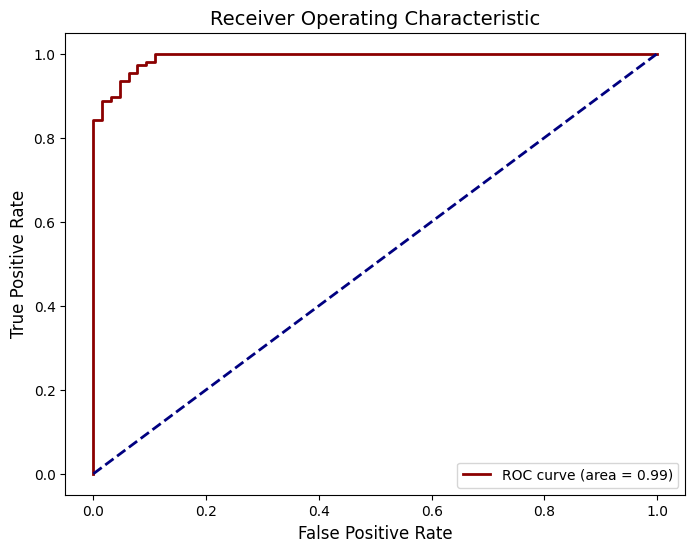

In [8]:
# 计算预测概率
y_proba = best_gbc.predict_proba(X_test_scaled)[:, 1]

# 计算ROC曲线
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkred', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Receiver Operating Characteristic', fontsize=14)
plt.legend(loc="lower right")
plt.show()

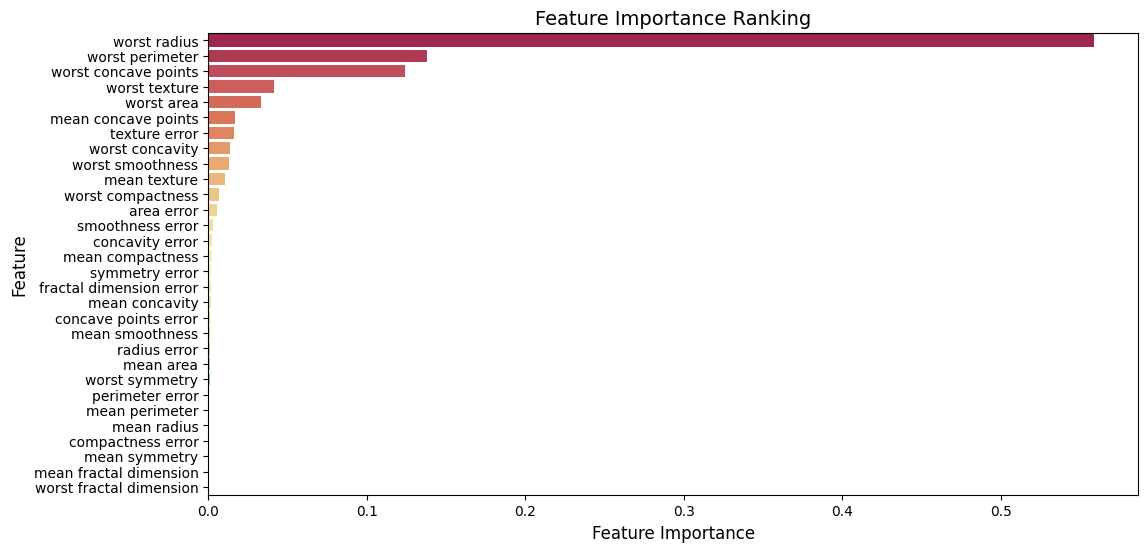

In [9]:
# 获取各特征的重要性
feature_importances = best_gbc.feature_importances_
features = X.columns

# 构造DataFrame，方便排序和展示
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='Spectral')
plt.xlabel('Feature Importance', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.title('Feature Importance Ranking', fontsize=14)
plt.show()

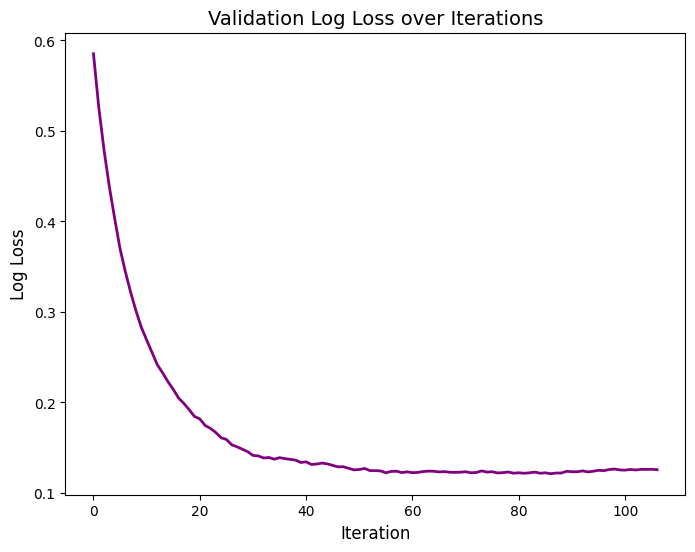

In [10]:
# 早停法优化
from sklearn.metrics import log_loss

gbc_early_stop = GradientBoostingClassifier(
    n_estimators=300,  # 较多迭代次数
    learning_rate=grid_search.best_params_['learning_rate'],
    max_depth=grid_search.best_params_['max_depth'],
    random_state=42,
    validation_fraction=0.1,  # 使用部分训练数据作为验证集
    n_iter_no_change=10  # 如果连续10次迭代验证集损失没有改善则提前停止训练
)

gbc_early_stop.fit(X_train_scaled, y_train)

losses = []
for y_proba in gbc_early_stop.staged_predict_proba(X_test_scaled):  # 仅GBDT,GBC有 它返回一个生成器（generator），可以按顺序遍历模型训练过程中的每一个迭代步（即每新增一棵树后），给出当前集成模型对样本的预测概率。
    loss = log_loss(y_test, y_proba)
    losses.append(loss)

plt.figure(figsize=(8, 6))
plt.plot(losses, color='purple', lw=2)
plt.xlabel('Iteration', fontsize=12)
plt.ylabel('Log Loss', fontsize=12)
plt.title('Validation Log Loss over Iterations', fontsize=14)
plt.show()

In [11]:
print("Early stopping iterations:", gbc_early_stop.n_estimators_)
print("Final Test Accuracy:", gbc_early_stop.score(X_test_scaled, y_test))

Early stopping iterations: 107
Final Test Accuracy: 0.9532163742690059


## 梯度提升模型的优缺点

### 优点

- **高预测性能**：梯度提升模型通过不断迭代地构建和优化多个弱分类器，可以捕捉复杂的数据模式，在许多任务中能取得较高的准确率和鲁棒性。
- **灵活性强**：模型可以通过调整诸如弱学习器数量、学习率、树的深度等超参数来平衡偏差与方差，适用于多种数据分布和问题场景。
- **内置特征选择**：在迭代过程中，梯度提升会自动对各特征进行重要性评估，有助于了解哪些变量对预测贡献较大，同时可辅助进行特征工程。
- **稳健性**：对异常值和部分噪声具有一定的鲁棒性，能较好地处理非线性关系和特征交互。

### 缺点

- **训练时间较长**：由于模型需要逐步构建多个弱学习器，尤其在超参数调优时计算代价较高，不适合实时或超大数据量的场景。
- **容易过拟合**：若超参数设置不当（如学习率过高或树的深度过深），模型可能出现过拟合问题，因此需要采用交叉验证、early stopping等策略。
- **参数调优复杂**：模型的性能对参数设置较为敏感，需要较多经验和计算资源来搜索最优参数组合。
- **解释性较弱**：虽然可以输出特征重要性，但整体模型结构相对复杂，不如单棵决策树直观，模型解释性相对较低。

## 梯度提升模型的适用场景

### 优选梯度提升的情况

- **预测精度要求高的场景**：当问题对预测准确性要求非常严格时，梯度提升算法由于其不断迭代优化的特性往往能获得更高的精度。
- **数据特征交互复杂**：当数据中存在大量非线性和复杂特征交互时，梯度提升能更好地捕捉这些信息，从而提高模型表现。
- **数据量适中**：对于中小规模的数据集，梯度提升的训练时间较为可控，且能充分发挥其模型优化能力。
- **特征选择需求**：当需要借助模型了解各特征的重要性时，梯度提升的内置特征评估能提供有价值的信息。

### 考虑其他算法的情况

- **实时或大规模数据场景**：当数据量极大或需要实时预测时，随机森林、LightGBM等在训练和预测速度上可能更有优势。
- **对训练时间要求较高的场景**：如果计算资源有限或调参时间紧张，随机森林或AdaBoost通常调参相对简单，训练速度更快。
- **解释性要求高的场景**：对于需要简单直观解释模型决策的场合，单棵决策树或简单的集成模型可能更合适，而梯度提升模型整体结构较复杂。
- **内存资源有限**：在资源受限的环境下，LightGBM由于内存消耗较低，可以作为梯度提升的替代选择。